## Things to check
 1. how additive constant is working
 2.  


In [9]:
import math
import matplotlib.pyplot as plt
import numpy as np 

In [6]:
X_raw = list(range(6))

def wavy(x):
    return x  + 2 + 0.1 * math.sin(10 * x)

X = [[x] for x in X_raw]
Y = [wavy(x) for x in X_raw]

print(X)
print(Y)



[[0], [1], [2], [3], [4], [5]]
[2.0, 2.9455978889110632, 4.091294525072763, 4.901196837590714, 6.074511316047935, 6.973762514629607]


In [7]:
X_test = [v/100 for v in range(501)] #X_test is a list of points sampled 0.01 apart that will be used to test the regressed functions later.

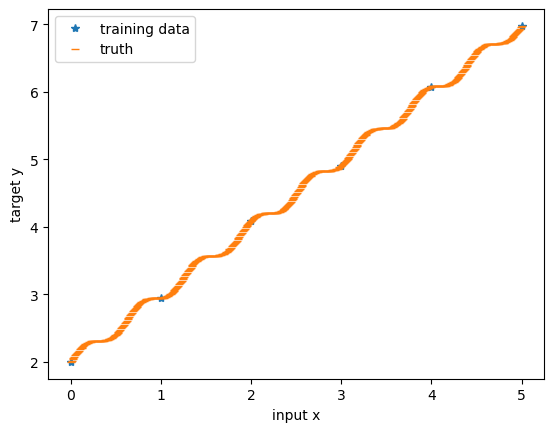

In [8]:
plt.plot(X, Y, "*", label="training data")
plt.plot(X_test, [wavy(x) for x in X_test], "_", label="truth")
plt.xlabel("input x")
plt.ylabel("target y")
plt.legend()
plt.show()

In [10]:
np.asarray(X)

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5]])

In [ ]:
coeffcients_only = np.linalg.lstsq(X, Y, rcond=None)[0] #  linear least squares solution
print(f"coeffcients_only: {coeffcients_only!r}")
print(f"model formula: y = {coeffcients_only[0]}x")

coeffcients_only: array([1.54542973])
model formula: y = 1.5454297325303368x


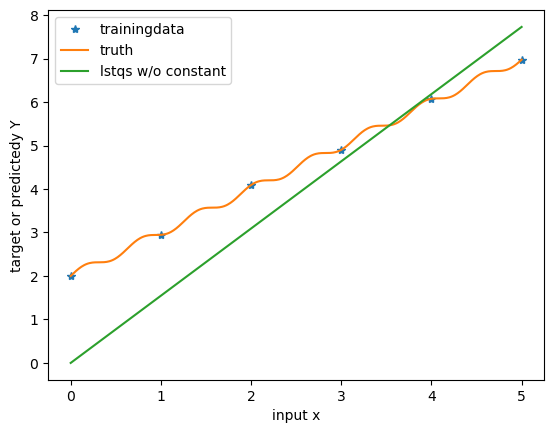

In [14]:
plt.plot([x[0] for x in X], Y, '*', label='trainingdata')
plt.plot(X_test, [wavy(x) for x in X_test], "-", label='truth')
plt.plot(X_test, [v * coeffcients_only[0] for v in X_test], label='lstqs w/o constant')
plt.xlabel('input x')
plt.ylabel('target or predictedy Y')
plt.legend()
plt.show()

In [15]:
import numpy as np
x = np.array([0, 1, 2, 3])
y = np.array([-1, 0.2, 0.9, 2.1])

In [ ]:
#Computes the vector x that approximately solves the equation a @ x = b
A = np.vstack([x, np.ones(len(x))]).T 
A

array([[0., 1.],
       [1., 1.],
       [2., 1.],
       [3., 1.]])

In [17]:
m, c = np.linalg.lstsq(A, y)[0]
m, c

/var/folders/yy/xrr6737d07b4bxk9rqk356480000gp/T/ipykernel_20645/3149831128.py:1: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  m, c = np.linalg.lstsq(A, y)[0]


(1.0, -0.9499999999999996)

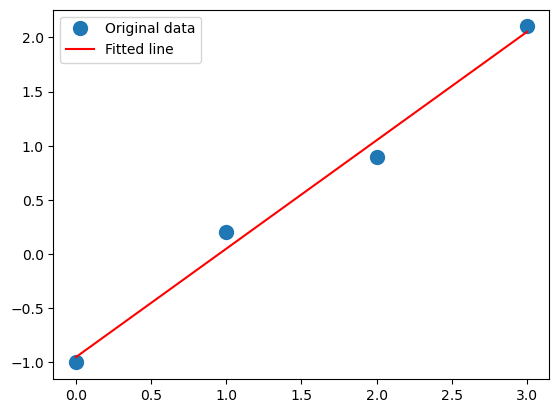

In [18]:
_ = plt.plot(x, y, 'o', label='Original data', markersize=10)
_ = plt.plot(x, m*x + c, 'r', label='Fitted line')
_ = plt.legend()
plt.show()

In [19]:
# this conversion has been happening automatically while calling NumPy and sklearn functions.
np.asarray(X)

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5]])

In [20]:
np.ones((len(X), 1))

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [21]:
X_with_constant = np.hstack((X, np.ones((len(X), 1))))
X_with_constant

array([[0., 1.],
       [1., 1.],
       [2., 1.],
       [3., 1.],
       [4., 1.],
       [5., 1.]])

In [22]:
bias = np.ones((3, 1))
bias

array([[1.],
       [1.],
       [1.]])

coefficient and constant = array([1.00187015, 1.99305181])
model formula: y = 1.0018701476307599x + 1.9930518112984474


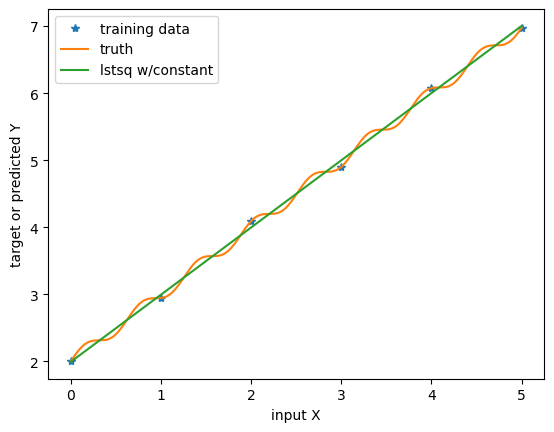

In [23]:
coefficient_and_constant = np.linalg.lstsq(X_with_constant, Y, rcond=None)[0]
print(f"coefficient and constant = {coefficient_and_constant!r}")
print(f"model formula: y = {coefficient_and_constant[0]}x + {coefficient_and_constant[1]}")
 
plt.plot([x[0] for x in X], Y, "*", label="training data")
plt.plot(X_test, [wavy(x) for x in X_test], "-", label="truth")
plt.plot(X_test, [v * coefficient_and_constant[0] + coefficient_and_constant[1] for v in X_test], label="lstsq w/constant")
plt.xlabel("input X")
plt.ylabel("target or predicted Y")
plt.legend()
plt.show()

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
sk_model = LinearRegression()
sk_model.fit(X, Y)
print(f"coefficients = {sk_model.coef_!r}")
print(f"intercept = {sk_model.intercept_!r}")
print(f"model formula: y = {sk_model.coef_[0]}x + {sk_model.intercept_}")

coefficients = array([1.00187015])
intercept = 1.993051811298446
model formula: y = 1.0018701476307603x + 1.993051811298446


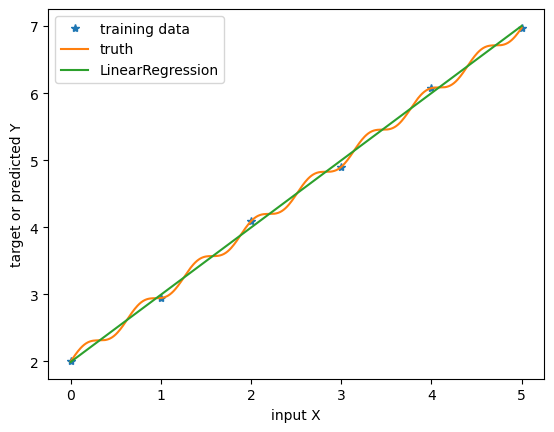

In [27]:
plt.plot([x[0] for x in X], Y, "*", label="training data")
plt.plot(X_test, [wavy(x) for x in X_test], "-", label="truth" )
plt.plot(X_test, sk_model.predict([[v] for v in X_test]), label="LinearRegression")
plt.xlabel("input X")
plt.ylabel("target or predicted Y")
plt.legend()
plt.show()